# **LSTM Model**


### Tahap A — Baseline Model Development
- model development dilakukan melalui eksperimen konfigurasi terbatas
- setiap konfigurasi dijalankan dengan beberapa random seed untuk mengurangi efek stochastic training

### Tahap B — Ablation Study
- Menggunakan konfigurasi LSTM yang sama.
- Membandingkan kontribusi kelompok fitur:
  - FULL
  - NO_G1
  - NO_G2
  - NO_G3
  - GOLD_ONLY

### Tahap C — Final Test Evaluation
- Menggunakan package fitur terbaik dari validation.
- Retrain pada train + validation.
- Evaluasi sekali pada test set.

Metrik:
- MAE
- RMSE
- Directional Accuracy

In [1]:
import json
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

warnings.filterwarnings("ignore")

### **Config**

In [2]:
PROJECT_ROOT = Path.cwd().resolve().parent
DATA_DIR = PROJECT_ROOT / "data" / "processed"
RESULTS_DIR = PROJECT_ROOT / "results" / "lstm_5d"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_PATH = DATA_DIR / "train_lstm_5d.csv"
VAL_PATH = DATA_DIR / "val_lstm_5d.csv"
TEST_PATH = DATA_DIR / "test_lstm_5d.csv"

DATE_COL = "DATE"
TARGET_DATE_COL = "TARGET_DATE"
TARGET_COL = "TARGET_5D"
DIRECTION_COL = "TARGET_DIRECTION"

RANDOM_STATE = 42
LSTM_WINDOW = 7
MAX_EPOCHS = 150
BATCH_SIZE = 16

CORE_FEATURE_BASES = [
    "GOLD_RET",
    "DXY_RET",
    "SP500_RET",
    "OIL_RET",
    "US10Y_CHANGE",
    "VIX_LEVEL",
]

# G1 - Dollar and rates
GROUP_1_DOLLAR_RATES = ["DXY_RET", "US10Y_CHANGE"]

# G2 - Risk sentiment
GROUP_2_RISK = ["SP500_RET", "VIX_LEVEL"]

# G3 - Commodity proxy
GROUP_3_COMMODITY = ["OIL_RET"]

print("DATA_DIR    :", DATA_DIR)
print("RESULTS_DIR :", RESULTS_DIR)

DATA_DIR    : C:\Users\Afzi\Documents\BINUS\0. SKRIPSI\gold_forecasting_skripsi\data\processed
RESULTS_DIR : C:\Users\Afzi\Documents\BINUS\0. SKRIPSI\gold_forecasting_skripsi\results\lstm_5d


In [3]:
def set_global_seed(seed=RANDOM_STATE):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    tf.keras.backend.clear_session()


set_global_seed(RANDOM_STATE)

### **Load Data**

In [4]:
train_df = pd.read_csv(TRAIN_PATH)
val_df = pd.read_csv(VAL_PATH)
test_df = pd.read_csv(TEST_PATH)

for df in [train_df, val_df, test_df]:
    df[DATE_COL] = pd.to_datetime(df[DATE_COL])
    df[TARGET_DATE_COL] = pd.to_datetime(df[TARGET_DATE_COL])
    df.sort_values(DATE_COL, inplace=True)
    df.reset_index(drop=True, inplace=True)

print("Train:", train_df.shape)
print("Val  :", val_df.shape)
print("Test :", test_df.shape)

display(train_df.head())

Train: (3257, 46)
Val  : (250, 46)
Test : (503, 46)


,DATE,TARGET_DATE,TARGET_5D,TARGET_DIRECTION,GOLD_RET_T0,DXY_RET_T0,SP500_RET_T0,OIL_RET_T0,US10Y_CHANGE_T0,VIX_LEVEL_T0,...,SP500_RET_T5,OIL_RET_T5,US10Y_CHANGE_T5,VIX_LEVEL_T5,GOLD_RET_T6,DXY_RET_T6,SP500_RET_T6,OIL_RET_T6,US10Y_CHANGE_T6,VIX_LEVEL_T6
0,2010-01-13,2010-01-21,-0.029655,0,0.000358,0.001161,0.003116,0.003190,-0.086,19.350000,...,-0.009381,-0.020965,-0.099,18.250000,0.006644,-0.001300,0.008326,-0.014111,0.064,17.850000
1,2010-01-14,2010-01-22,-0.046736,0,0.015920,-0.001675,0.000546,0.017244,0.053,19.160000,...,0.008326,-0.014111,0.064,17.850000,0.005456,-0.001561,0.002426,-0.003264,-0.049,17.629999
2,2010-01-15,2010-01-25,-0.030882,0,-0.002465,0.005420,0.004001,-0.006251,0.014,19.059999,...,0.002426,-0.003264,-0.049,17.629999,-0.010940,0.007689,-0.010823,-0.017508,-0.058,17.910000
3,2010-01-19,2010-01-26,-0.036676,0,0.004501,-0.005648,0.002882,0.001089,-0.014,18.129999,...,-0.010823,-0.017508,-0.058,17.910000,0.008495,0.002328,0.012500,0.013077,0.031,17.580000
4,2010-01-20,2010-01-27,-0.025083,0,0.010982,-0.006067,0.001747,-0.002779,0.010,17.549999,...,0.012500,0.013077,0.031,17.580000,-0.024041,0.010839,-0.010598,-0.017717,-0.048,18.680000


### **Define feature groups**

Feature groups mengikuti scope penelitian:

- Group 1: Dollar & rates
  - DXY_RET
  - US10Y_CHANGE

- Group 2: Risk sentiment
  - SP500_RET
  - VIX_LEVEL

- Group 3: Commodity / inflation proxy
  - OIL_RET

Selain itu, GOLD_RET dipisahkan sebagai informasi internal emas.

In [5]:
def sequence_cols_for_bases(bases):
    cols = []
    for step in range(LSTM_WINDOW):
        for base in bases:
            cols.append(f"{base}_T{step}")
    return cols


FULL_BASES = CORE_FEATURE_BASES.copy()

# NO_G1: menghapus kelompok dollar and rates
# G1 = DXY_RET, US10Y_CHANGE
NO_G1_BASES = [
    base for base in CORE_FEATURE_BASES
    if base not in GROUP_1_DOLLAR_RATES
]

# NO_G2: menghapus kelompok risk sentiment
# G2 = SP500_RET, VIX_LEVEL
NO_G2_BASES = [
    base for base in CORE_FEATURE_BASES
    if base not in GROUP_2_RISK
]

# NO_G3: menghapus kelompok commodity proxy
# G3 = OIL_RET
NO_G3_BASES = [
    base for base in CORE_FEATURE_BASES
    if base not in GROUP_3_COMMODITY
]

GOLD_ONLY_BASES = ["GOLD_RET"]

FEATURE_PACKAGES = {
    "FULL": {
        "bases": FULL_BASES,
        "cols": sequence_cols_for_bases(FULL_BASES),
    },
    "NO_G1": {
        "bases": NO_G1_BASES,
        "cols": sequence_cols_for_bases(NO_G1_BASES),
    },
    "NO_G2": {
        "bases": NO_G2_BASES,
        "cols": sequence_cols_for_bases(NO_G2_BASES),
    },
    "NO_G3": {
        "bases": NO_G3_BASES,
        "cols": sequence_cols_for_bases(NO_G3_BASES),
    },
    "GOLD_ONLY": {
        "bases": GOLD_ONLY_BASES,
        "cols": sequence_cols_for_bases(GOLD_ONLY_BASES),
    },
}

for package_name, package in FEATURE_PACKAGES.items():
    print(
        f"{package_name:10s}: "
        f"{len(package['bases'])} base features, "
        f"{len(package['cols'])} sequence columns"
    )

FULL      : 6 base features, 42 sequence columns
NO_G1     : 4 base features, 28 sequence columns
NO_G2     : 4 base features, 28 sequence columns
NO_G3     : 5 base features, 35 sequence columns
GOLD_ONLY : 1 base features, 7 sequence columns


In [6]:
required_cols = {DATE_COL, TARGET_DATE_COL, TARGET_COL, DIRECTION_COL}

for package in FEATURE_PACKAGES.values():
    required_cols.update(package["cols"])

for name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    missing = required_cols - set(df.columns)
    if missing:
        raise ValueError(f"{name} data missing columns: {sorted(missing)}")

print("All required columns are available.")

All required columns are available.


### **Helper Functions**

In [7]:
def directional_accuracy(y_true, y_pred):
    y_true_dir = (np.array(y_true) > 0).astype(int)
    y_pred_dir = (np.array(y_pred) > 0).astype(int)
    return float((y_true_dir == y_pred_dir).mean())


def compute_metrics(y_true, y_pred):
    return {
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "DA": float(directional_accuracy(y_true, y_pred)),
    }

In [8]:
def prepare_lstm_data(train_data, eval_data, feature_cols, n_base_features):
    X_train_flat = train_data[feature_cols].values
    X_eval_flat = eval_data[feature_cols].values

    y_train = train_data[[TARGET_COL]].values
    y_eval = eval_data[[TARGET_COL]].values

    x_scaler = StandardScaler()
    y_scaler = StandardScaler()

    X_train_scaled_flat = x_scaler.fit_transform(X_train_flat)
    X_eval_scaled_flat = x_scaler.transform(X_eval_flat)

    y_train_scaled = y_scaler.fit_transform(y_train).ravel()

    X_train_scaled = X_train_scaled_flat.reshape(
        len(train_data), LSTM_WINDOW, n_base_features
    )

    X_eval_scaled = X_eval_scaled_flat.reshape(
        len(eval_data), LSTM_WINDOW, n_base_features
    )

    return {
        "X_train": X_train_scaled,
        "y_train_scaled": y_train_scaled,
        "X_eval": X_eval_scaled,
        "y_eval_original": y_eval.ravel(),
        "x_scaler": x_scaler,
        "y_scaler": y_scaler,
    }

In [9]:
def build_lstm_model(config, input_shape, seed):
    set_global_seed(seed)

    model = Sequential()
    model.add(Input(shape=input_shape))

    if config["architecture"] == "SMALL":
        model.add(LSTM(32))
        model.add(Dropout(0.2))

    elif config["architecture"] == "MEDIUM":
        model.add(LSTM(64, return_sequences=True))
        model.add(Dropout(0.2))
        model.add(LSTM(32))
        model.add(Dropout(0.2))

    else:
        raise ValueError(f"Unknown architecture: {config['architecture']}")

    model.add(Dense(1))

    optimizer = tf.keras.optimizers.Adam(learning_rate=config["learning_rate"])

    model.compile(
        optimizer=optimizer,
        loss=tf.keras.losses.Huber(),
    )

    return model


def get_callbacks():
    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=EARLY_STOPPING_PATIENCE,
        restore_best_weights=True,
        verbose=0,
    )

    reduce_lr = ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=LR_PATIENCE,
        min_lr=1e-6,
        verbose=0,
    )

    return [early_stop, reduce_lr]

In [10]:
def build_lstm_model(input_shape, architecture, learning_rate):
    model = Sequential()

    model.add(Input(shape=input_shape))

    if architecture == "SMALL":
        model.add(LSTM(32))
        model.add(Dropout(0.2))

    elif architecture == "MEDIUM":
        model.add(LSTM(64, return_sequences=True))
        model.add(Dropout(0.2))
        model.add(LSTM(32))
        model.add(Dropout(0.2))

    else:
        raise ValueError(f"Unknown architecture: {architecture}")

    model.add(Dense(1))

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss=tf.keras.losses.Huber(),
    )

    return model

In [11]:
def get_callbacks():
    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=15,
        restore_best_weights=True,
        verbose=0,
    )

    reduce_lr = ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=7,
        min_lr=1e-5,
        verbose=0,
    )

    return [early_stop, reduce_lr]

In [12]:
def train_eval_lstm(
    train_data,
    eval_data,
    feature_cols,
    n_base_features,
    architecture,
    learning_rate,
    seed=RANDOM_STATE,
):
    set_global_seed(seed)

    prepared = prepare_lstm_data(
        train_data=train_data,
        eval_data=eval_data,
        feature_cols=feature_cols,
        n_base_features=n_base_features,
    )

    model = build_lstm_model(
        input_shape=(LSTM_WINDOW, n_base_features),
        architecture=architecture,
        learning_rate=learning_rate,
    )

    history = model.fit(
        prepared["X_train"],
        prepared["y_train_scaled"],
        validation_data=(
            prepared["X_eval"],
            prepared["y_scaler"].transform(eval_data[[TARGET_COL]].values).ravel(),
        ),
        epochs=MAX_EPOCHS,
        batch_size=BATCH_SIZE,
        shuffle=False,
        callbacks=get_callbacks(),
        verbose=0,
    )

    pred_scaled = model.predict(prepared["X_eval"], verbose=0).ravel()
    pred_original = prepared["y_scaler"].inverse_transform(
        pred_scaled.reshape(-1, 1)
    ).ravel()

    pred_df = eval_data[[DATE_COL, TARGET_DATE_COL, TARGET_COL, DIRECTION_COL]].copy()
    pred_df["PRED"] = pred_original
    pred_df["PRED_DIRECTION"] = (pred_df["PRED"] > 0).astype(int)

    metrics = compute_metrics(prepared["y_eval_original"], pred_original)

    best_epoch = int(np.argmin(history.history["val_loss"]) + 1)
    best_val_loss = float(np.min(history.history["val_loss"]))

    return {
        "model": model,
        "history": history,
        "pred_df": pred_df,
        "metrics": metrics,
        "best_epoch": best_epoch,
        "best_val_loss": best_val_loss,
        "x_scaler": prepared["x_scaler"],
        "y_scaler": prepared["y_scaler"],
    }

In [13]:
def prediction_diagnostics(pred_df, label=""):
    pred_values = pred_df["PRED"].values

    diagnostics = {
        "label": label,
        "pred_mean": float(np.mean(pred_values)),
        "pred_std": float(np.std(pred_values)),
        "pred_min": float(np.min(pred_values)),
        "pred_max": float(np.max(pred_values)),
        "unique_pred_count_rounded_10": int(len(np.unique(np.round(pred_values, 10)))),
        "positive_pred_ratio": float((pred_values > 0).mean()),
        "positive_actual_ratio": float((pred_df[TARGET_COL].values > 0).mean()),
    }

    print(f"\n===== Prediction Diagnostics: {label} =====")
    for key, value in diagnostics.items():
        print(f"{key}: {value}")

    if diagnostics["unique_pred_count_rounded_10"] <= 1:
        print("WARNING: predictions are constant or nearly constant.")

    return diagnostics

### **Tahap A - Model development**

dilakukan menggunakan package fitur `FULL`.

Konfigurasi yang diuji:
- SMALL, learning rate 0.001
- SMALL, learning rate 0.0005
- MEDIUM, learning rate 0.001
- MEDIUM, learning rate 0.0005

Seleksi utama:
- MAE validation

In [14]:
STAGE_A_CONFIGS = [
    {"config_name": "SMALL_LR_001", "architecture": "SMALL", "learning_rate": 0.001},
    {"config_name": "SMALL_LR_0005", "architecture": "SMALL", "learning_rate": 0.0005},
    {"config_name": "MEDIUM_LR_001", "architecture": "MEDIUM", "learning_rate": 0.001},
    {"config_name": "MEDIUM_LR_0005", "architecture": "MEDIUM", "learning_rate": 0.0005},
]

stage_a_rows = []
stage_a_predictions = {}

full_package = FEATURE_PACKAGES["FULL"]
full_feature_cols = full_package["cols"]
full_n_base_features = len(full_package["bases"])

for config in STAGE_A_CONFIGS:
    print(f"Training config: {config['config_name']}")

    result = train_eval_lstm(
        train_data=train_df,
        eval_data=val_df,
        feature_cols=full_feature_cols,
        n_base_features=full_n_base_features,
        architecture=config["architecture"],
        learning_rate=config["learning_rate"],
        seed=RANDOM_STATE,
    )

    metrics = result["metrics"]

    pred_df = result["pred_df"].copy()
    pred_df["CONFIG"] = config["config_name"]
    stage_a_predictions[config["config_name"]] = pred_df

    stage_a_rows.append({
        "config_name": config["config_name"],
        "architecture": config["architecture"],
        "learning_rate": config["learning_rate"],
        "loss": "Huber",
        "best_epoch": result["best_epoch"],
        "best_val_loss_scaled": result["best_val_loss"],
        "MAE": metrics["MAE"],
        "RMSE": metrics["RMSE"],
        "DA": metrics["DA"],
    })

    print(
        f"{config['config_name']} | "
        f"epoch={result['best_epoch']} | "
        f"MAE={metrics['MAE']:.6f} | "
        f"RMSE={metrics['RMSE']:.6f} | "
        f"DA={metrics['DA']:.4f}"
    )

Training config: SMALL_LR_001
SMALL_LR_001 | epoch=19 | MAE=0.014794 | RMSE=0.018857 | DA=0.5240
Training config: SMALL_LR_0005
SMALL_LR_0005 | epoch=5 | MAE=0.014863 | RMSE=0.018784 | DA=0.5360
Training config: MEDIUM_LR_001
MEDIUM_LR_001 | epoch=16 | MAE=0.014739 | RMSE=0.018821 | DA=0.5240
Training config: MEDIUM_LR_0005
MEDIUM_LR_0005 | epoch=3 | MAE=0.014924 | RMSE=0.018814 | DA=0.4640


In [15]:
stage_a_results = pd.DataFrame(stage_a_rows)
stage_a_results = stage_a_results.sort_values(
    by=["MAE", "RMSE", "DA"],
    ascending=[True, True, False]
).reset_index(drop=True)

display(stage_a_results)

,config_name,architecture,learning_rate,loss,best_epoch,best_val_loss_scaled,MAE,RMSE,DA
0,MEDIUM_LR_001,MEDIUM,0.0010,Huber,16,0.316175,0.014739,0.018821,0.524
1,SMALL_LR_001,SMALL,0.0010,Huber,19,0.317350,0.014794,0.018857,0.524
2,SMALL_LR_0005,SMALL,0.0005,Huber,5,0.316196,0.014863,0.018784,0.536
3,MEDIUM_LR_0005,MEDIUM,0.0005,Huber,3,0.316470,0.014924,0.018814,0.464


In [16]:
BEST_STAGE_A = stage_a_results.iloc[0].copy()

BEST_CONFIG = {
    "config_name": BEST_STAGE_A["config_name"],
    "architecture": BEST_STAGE_A["architecture"],
    "learning_rate": float(BEST_STAGE_A["learning_rate"]),
    "loss": "Huber",
}

print("Best Stage A config")
print(BEST_CONFIG)
print("Val MAE :", BEST_STAGE_A["MAE"])
print("Val RMSE:", BEST_STAGE_A["RMSE"])
print("Val DA  :", BEST_STAGE_A["DA"])

Best Stage A config
{'config_name': 'MEDIUM_LR_001', 'architecture': 'MEDIUM', 'learning_rate': 0.001, 'loss': 'Huber'}
Val MAE : 0.014739008226045212
Val RMSE: 0.018821093387770337
Val DA  : 0.524


In [17]:
stage_a_path = RESULTS_DIR / "stage_a_lstm_model_development_5d.csv"
stage_a_results.to_csv(stage_a_path, index=False)

stage_a_pred_path = RESULTS_DIR / "lstm_stage_a_validation_predictions_5d.csv"
pd.concat(stage_a_predictions.values(), axis=0, ignore_index=True).to_csv(
    stage_a_pred_path,
    index=False,
)

print("Saved:", stage_a_path)
print("Saved:", stage_a_pred_path)

Saved: C:\Users\Afzi\Documents\BINUS\0. SKRIPSI\gold_forecasting_skripsi\results\lstm_5d\stage_a_lstm_model_development_5d.csv
Saved: C:\Users\Afzi\Documents\BINUS\0. SKRIPSI\gold_forecasting_skripsi\results\lstm_5d\lstm_stage_a_validation_predictions_5d.csv


### **Tahap B - Ablation on validation**

Semua package diuji dengan konfigurasi Konfigurasi LSTM terbaik dari Tahap A.

Setiap feature package diuji pada validation set menggunakan beberapa seed.

Package terbaik dipilih berdasarkan:
1. MAE
2. RMSE
3. Directional Accuracy

Pemilihan dilakukan pada validation set.

In [18]:
stage_b_rows = []
stage_b_predictions = {}
stage_b_diagnostics = {}

for package_name, package in FEATURE_PACKAGES.items():
    print(f"Training package: {package_name}")

    result = train_eval_lstm(
        train_data=train_df,
        eval_data=val_df,
        feature_cols=package["cols"],
        n_base_features=len(package["bases"]),
        architecture=BEST_CONFIG["architecture"],
        learning_rate=BEST_CONFIG["learning_rate"],
        seed=RANDOM_STATE,
    )

    metrics = result["metrics"]

    pred_df = result["pred_df"].copy()
    pred_df["PACKAGE"] = package_name
    stage_b_predictions[package_name] = pred_df

    diagnostics = prediction_diagnostics(
        pred_df=pred_df,
        label=f"Validation - {package_name}",
    )
    stage_b_diagnostics[package_name] = diagnostics

    stage_b_rows.append({
        "package": package_name,
        "num_base_features": len(package["bases"]),
        "num_sequence_features": len(package["cols"]),
        "base_features": ", ".join(package["bases"]),
        "architecture": BEST_CONFIG["architecture"],
        "learning_rate": BEST_CONFIG["learning_rate"],
        "loss": "Huber",
        "best_epoch": result["best_epoch"],
        "best_val_loss_scaled": result["best_val_loss"],
        "MAE": metrics["MAE"],
        "RMSE": metrics["RMSE"],
        "DA": metrics["DA"],
    })

    print(
        f"{package_name:10s} | "
        f"epoch={result['best_epoch']} | "
        f"MAE={metrics['MAE']:.6f} | "
        f"RMSE={metrics['RMSE']:.6f} | "
        f"DA={metrics['DA']:.4f}"
    )

Training package: FULL

===== Prediction Diagnostics: Validation - FULL =====
label: Validation - FULL
pred_mean: 0.0008084263536147773
pred_std: 0.002140803262591362
pred_min: -0.004765904974192381
pred_max: 0.011675823479890823
unique_pred_count_rounded_10: 250
positive_pred_ratio: 0.644
positive_actual_ratio: 0.52
FULL       | epoch=16 | MAE=0.014739 | RMSE=0.018821 | DA=0.5240
Training package: NO_G1

===== Prediction Diagnostics: Validation - NO_G1 =====
label: Validation - NO_G1
pred_mean: 0.0011179106077179313
pred_std: 0.0013378364965319633
pred_min: -0.0037871389649808407
pred_max: 0.006676241755485535
unique_pred_count_rounded_10: 250
positive_pred_ratio: 0.82
positive_actual_ratio: 0.52
NO_G1      | epoch=22 | MAE=0.014736 | RMSE=0.018658 | DA=0.5320
Training package: NO_G2

===== Prediction Diagnostics: Validation - NO_G2 =====
label: Validation - NO_G2
pred_mean: 0.0011361842043697834
pred_std: 0.0013765213079750538
pred_min: -0.002861983375623822
pred_max: 0.0058525842614

In [19]:
stage_b_results = pd.DataFrame(stage_b_rows)
stage_b_results = stage_b_results.sort_values(
    by=["MAE", "RMSE", "DA"],
    ascending=[True, True, False]
).reset_index(drop=True)

display(stage_b_results)

,package,num_base_features,num_sequence_features,base_features,architecture,learning_rate,loss,best_epoch,best_val_loss_scaled,MAE,RMSE,DA
0,NO_G3,5,35,"GOLD_RET, DXY_RET, SP500_RET, US10Y_CHANGE, VI...",MEDIUM,0.001,Huber,14,0.312849,0.014633,0.018731,0.544
1,NO_G1,4,28,"GOLD_RET, SP500_RET, OIL_RET, VIX_LEVEL",MEDIUM,0.001,Huber,22,0.311558,0.014736,0.018658,0.532
2,FULL,6,42,"GOLD_RET, DXY_RET, SP500_RET, OIL_RET, US10Y_C...",MEDIUM,0.001,Huber,16,0.316175,0.014739,0.018821,0.524
3,NO_G2,4,28,"GOLD_RET, DXY_RET, OIL_RET, US10Y_CHANGE",MEDIUM,0.001,Huber,9,0.313754,0.014838,0.018692,0.500
4,GOLD_ONLY,1,7,GOLD_RET,MEDIUM,0.001,Huber,6,0.317454,0.014982,0.018849,0.488


In [20]:
BEST_STAGE_B = stage_b_results.iloc[0].copy()
BEST_PACKAGE = BEST_STAGE_B["package"]
BEST_PACKAGE_INFO = FEATURE_PACKAGES[BEST_PACKAGE]
BEST_EPOCHS = int(BEST_STAGE_B["best_epoch"])

print("Best package :", BEST_PACKAGE)
print("Base features:", BEST_PACKAGE_INFO["bases"])
print("Best epochs  :", BEST_EPOCHS)
print("Val MAE      :", BEST_STAGE_B["MAE"])
print("Val RMSE     :", BEST_STAGE_B["RMSE"])
print("Val DA       :", BEST_STAGE_B["DA"])

Best package : NO_G3
Base features: ['GOLD_RET', 'DXY_RET', 'SP500_RET', 'US10Y_CHANGE', 'VIX_LEVEL']
Best epochs  : 14
Val MAE      : 0.014632944791553065
Val RMSE     : 0.01873093042223123
Val DA       : 0.544


In [21]:
stage_b_path = RESULTS_DIR / "stage_b_ablation_lstm_5d.csv"
stage_b_results.to_csv(stage_b_path, index=False)

stage_b_pred_path = RESULTS_DIR / "lstm_validation_predictions_5d.csv"
pd.concat(stage_b_predictions.values(), axis=0, ignore_index=True).to_csv(
    stage_b_pred_path,
    index=False,
)

stage_b_diag_path = RESULTS_DIR / "stage_b_diagnostics_lstm_5d.csv"
pd.DataFrame(stage_b_diagnostics.values()).to_csv(stage_b_diag_path, index=False)

print("Saved:", stage_b_path)
print("Saved:", stage_b_pred_path)
print("Saved:", stage_b_diag_path)

Saved: C:\Users\Afzi\Documents\BINUS\0. SKRIPSI\gold_forecasting_skripsi\results\lstm_5d\stage_b_ablation_lstm_5d.csv
Saved: C:\Users\Afzi\Documents\BINUS\0. SKRIPSI\gold_forecasting_skripsi\results\lstm_5d\lstm_validation_predictions_5d.csv
Saved: C:\Users\Afzi\Documents\BINUS\0. SKRIPSI\gold_forecasting_skripsi\results\lstm_5d\stage_b_diagnostics_lstm_5d.csv


### **Tahap C - Final test evaluation**

Model final:
- menggunakan konfigurasi terbaik dari Tahap A
- menggunakan package fitur terbaik dari Tahap B
- dilatih ulang pada train + validation
- dievaluasi sekali pada test set

In [22]:
def train_final_lstm(
    train_data,
    test_data,
    feature_cols,
    n_base_features,
    architecture,
    learning_rate,
    epochs,
    seed=RANDOM_STATE,
):
    set_global_seed(seed)

    X_train_flat = train_data[feature_cols].values
    X_test_flat = test_data[feature_cols].values

    y_train = train_data[[TARGET_COL]].values
    y_test = test_data[[TARGET_COL]].values

    x_scaler = StandardScaler()
    y_scaler = StandardScaler()

    X_train_scaled_flat = x_scaler.fit_transform(X_train_flat)
    X_test_scaled_flat = x_scaler.transform(X_test_flat)

    y_train_scaled = y_scaler.fit_transform(y_train).ravel()

    X_train_scaled = X_train_scaled_flat.reshape(
        len(train_data), LSTM_WINDOW, n_base_features
    )

    X_test_scaled = X_test_scaled_flat.reshape(
        len(test_data), LSTM_WINDOW, n_base_features
    )

    model = build_lstm_model(
        input_shape=(LSTM_WINDOW, n_base_features),
        architecture=architecture,
        learning_rate=learning_rate,
    )

    history = model.fit(
        X_train_scaled,
        y_train_scaled,
        epochs=epochs,
        batch_size=BATCH_SIZE,
        shuffle=False,
        verbose=0,
    )

    pred_scaled = model.predict(X_test_scaled, verbose=0).ravel()
    pred_original = y_scaler.inverse_transform(
        pred_scaled.reshape(-1, 1)
    ).ravel()

    pred_df = test_data[[DATE_COL, TARGET_DATE_COL, TARGET_COL, DIRECTION_COL]].copy()
    pred_df["PRED"] = pred_original
    pred_df["PRED_DIRECTION"] = (pred_df["PRED"] > 0).astype(int)

    metrics = compute_metrics(y_test.ravel(), pred_original)

    return {
        "model": model,
        "history": history,
        "pred_df": pred_df,
        "metrics": metrics,
        "x_scaler": x_scaler,
        "y_scaler": y_scaler,
    }

In [23]:
train_val_df = pd.concat([train_df, val_df], axis=0, ignore_index=True)

final_result = train_final_lstm(
    train_data=train_val_df,
    test_data=test_df,
    feature_cols=BEST_PACKAGE_INFO["cols"],
    n_base_features=len(BEST_PACKAGE_INFO["bases"]),
    architecture=BEST_CONFIG["architecture"],
    learning_rate=BEST_CONFIG["learning_rate"],
    epochs=BEST_EPOCHS,
    seed=RANDOM_STATE,
)

final_test_pred_df = final_result["pred_df"]
final_test_metrics = final_result["metrics"]
final_model = final_result["model"]

display(final_test_pred_df.head())

,DATE,TARGET_DATE,TARGET_5D,TARGET_DIRECTION,PRED,PRED_DIRECTION
0,2023-12-22,2024-01-02,0.003549,1,0.000772,1
1,2023-12-26,2024-01-03,-0.011661,0,0.000920,1
2,2023-12-27,2024-01-04,-0.019021,0,0.001060,1
3,2023-12-28,2024-01-05,-0.015189,0,0.000249,1
4,2023-12-29,2024-01-08,-0.017358,0,-0.000673,0


In [24]:
final_test_diagnostics = prediction_diagnostics(
    pred_df=final_test_pred_df,
    label="Final Test",
)


===== Prediction Diagnostics: Final Test =====
label: Final Test
pred_mean: 0.0008215774432756007
pred_std: 0.0038364308420568705
pred_min: -0.025062330067157745
pred_max: 0.017713891342282295
unique_pred_count_rounded_10: 503
positive_pred_ratio: 0.6719681908548708
positive_actual_ratio: 0.6540755467196819


In [25]:
print("Final Test Metrics")
print(f"MAE  : {final_test_metrics['MAE']:.6f}")
print(f"RMSE : {final_test_metrics['RMSE']:.6f}")
print(f"DA   : {final_test_metrics['DA']:.4f}")

Final Test Metrics
MAE  : 0.018761
RMSE : 0.024231
DA   : 0.6044


In [26]:
test_pred_path = RESULTS_DIR / "lstm_test_predictions_5d.csv"
final_test_pred_df.to_csv(test_pred_path, index=False)

print("Saved:", test_pred_path)

Saved: C:\Users\Afzi\Documents\BINUS\0. SKRIPSI\gold_forecasting_skripsi\results\lstm_5d\lstm_test_predictions_5d.csv


### **Benchmarks**

In [27]:
def zero_benchmark(eval_df):
    pred_df = eval_df[[DATE_COL, TARGET_DATE_COL, TARGET_COL, DIRECTION_COL]].copy()
    pred_df["PRED"] = 0.0
    pred_df["PRED_DIRECTION"] = 0
    metrics = compute_metrics(pred_df[TARGET_COL], pred_df["PRED"])
    return pred_df, metrics


def persistence_benchmark(train_hist_df, eval_df):
    """
    Horizon-aware persistence benchmark.

    Pada DATE = t, benchmark hanya memakai TARGET_5D terakhir
    yang sudah diketahui, yaitu observasi dengan TARGET_DATE <= t.
    """
    observed_pool = train_hist_df.copy().reset_index(drop=True)
    eval_df = eval_df.copy().reset_index(drop=True)

    preds = []
    history_sizes = []

    for i in range(len(eval_df)):
        next_row = eval_df.iloc[[i]].copy()
        current_date = next_row[DATE_COL].iloc[0]

        eligible_history = observed_pool[
            observed_pool[TARGET_DATE_COL] <= current_date
        ].copy().reset_index(drop=True)

        if eligible_history.empty:
            pred = 0.0
            history_size = 0
        else:
            pred = float(eligible_history[TARGET_COL].iloc[-1])
            history_size = len(eligible_history)

        preds.append(pred)
        history_sizes.append(history_size)

        observed_pool = pd.concat([observed_pool, next_row], axis=0, ignore_index=True)

    pred_df = eval_df[[DATE_COL, TARGET_DATE_COL, TARGET_COL, DIRECTION_COL]].copy()
    pred_df["PRED"] = preds
    pred_df["PRED_DIRECTION"] = (pred_df["PRED"] > 0).astype(int)
    pred_df["HISTORY_SIZE"] = history_sizes

    metrics = compute_metrics(pred_df[TARGET_COL], pred_df["PRED"])
    return pred_df, metrics

In [28]:
zero_pred_df, zero_metrics = zero_benchmark(test_df)
persist_pred_df, persist_metrics = persistence_benchmark(train_val_df, test_df)

benchmark_results = pd.DataFrame([
    {"benchmark": "ZERO", **zero_metrics},
    {"benchmark": "PERSISTENCE", **persist_metrics},
])

display(benchmark_results)

,benchmark,MAE,RMSE,DA
0,ZERO,0.019073,0.024538,0.345924
1,PERSISTENCE,0.026170,0.034550,0.530815


In [29]:
benchmark_path = RESULTS_DIR / "lstm_benchmarks_5d.csv"
benchmark_results.to_csv(benchmark_path, index=False)

print("Saved:", benchmark_path)

Saved: C:\Users\Afzi\Documents\BINUS\0. SKRIPSI\gold_forecasting_skripsi\results\lstm_5d\lstm_benchmarks_5d.csv


### **Actual vs Pred**

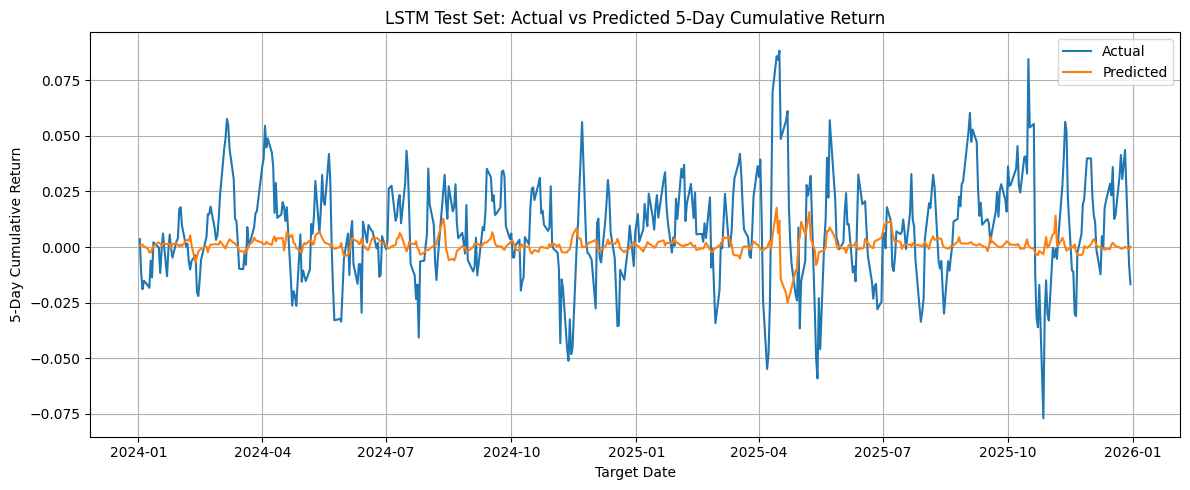

In [30]:
plot_df = final_test_pred_df.copy()
plot_df = plot_df.sort_values(TARGET_DATE_COL).reset_index(drop=True)

plt.figure(figsize=(12, 5))
plt.plot(plot_df[TARGET_DATE_COL], plot_df[TARGET_COL], label="Actual")
plt.plot(plot_df[TARGET_DATE_COL], plot_df["PRED"], label="Predicted")
plt.title("LSTM Test Set: Actual vs Predicted 5-Day Cumulative Return")
plt.xlabel("Target Date")
plt.ylabel("5-Day Cumulative Return")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### **Final Summary**

In [31]:
summary = {
    "model": "LSTM",
    "target": TARGET_COL,
    "window": LSTM_WINDOW,
    "selection_rule": "best LSTM configuration selected by validation MAE; RMSE and DA used as secondary checks",
    "scaling_policy": "StandardScaler fitted on train only for Stage A/B; fitted on train+validation for final test",
    "loss": "Huber",
    "batch_size": BATCH_SIZE,
    "max_epochs": MAX_EPOCHS,
    "best_config": BEST_CONFIG,
    "best_package": BEST_PACKAGE,
    "best_base_features": BEST_PACKAGE_INFO["bases"],
    "best_sequence_feature_cols": BEST_PACKAGE_INFO["cols"],
    "best_epochs": BEST_EPOCHS,
    "validation_metrics_best_package": {
        "MAE": float(BEST_STAGE_B["MAE"]),
        "RMSE": float(BEST_STAGE_B["RMSE"]),
        "DA": float(BEST_STAGE_B["DA"]),
    },
    "test_metrics": {
        "MAE": float(final_test_metrics["MAE"]),
        "RMSE": float(final_test_metrics["RMSE"]),
        "DA": float(final_test_metrics["DA"]),
    },
    "benchmark_metrics": {
        "ZERO": zero_metrics,
        "PERSISTENCE": persist_metrics,
    },
    "diagnostics": {
        "final_test": final_test_diagnostics,
    },
    "row_counts": {
        "train": int(len(train_df)),
        "validation": int(len(val_df)),
        "test": int(len(test_df)),
        "train_plus_validation": int(len(train_val_df)),
    },
    "files": {
        "stage_a_results": str(stage_a_path),
        "stage_a_predictions": str(stage_a_pred_path),
        "stage_b_results": str(stage_b_path),
        "stage_b_predictions": str(stage_b_pred_path),
        "stage_b_diagnostics": str(stage_b_diag_path),
        "test_predictions": str(test_pred_path),
        "benchmarks": str(benchmark_path),
    },
}

summary_path = RESULTS_DIR / "lstm_summary_5d.json"
with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)

print("Saved:", summary_path)

Saved: C:\Users\Afzi\Documents\BINUS\0. SKRIPSI\gold_forecasting_skripsi\results\lstm_5d\lstm_summary_5d.json


In [32]:
print("\n===== LSTM 5D SUMMARY =====")
print("Train rows        :", len(train_df))
print("Validation rows   :", len(val_df))
print("Test rows         :", len(test_df))
print("Window            :", LSTM_WINDOW)
print("Best config       :", BEST_CONFIG)
print("Best package      :", BEST_PACKAGE)
print("Best base features:", BEST_PACKAGE_INFO["bases"])
print("Best epochs       :", BEST_EPOCHS)

print("\nValidation")
print(f"MAE               : {BEST_STAGE_B['MAE']:.6f}")
print(f"RMSE              : {BEST_STAGE_B['RMSE']:.6f}")
print(f"DA                : {BEST_STAGE_B['DA']:.4f}")

print("\nTest")
print(f"MAE               : {final_test_metrics['MAE']:.6f}")
print(f"RMSE              : {final_test_metrics['RMSE']:.6f}")
print(f"DA                : {final_test_metrics['DA']:.4f}")

print("\nBenchmarks")
print(f"Zero MAE          : {zero_metrics['MAE']:.6f}")
print(f"Zero RMSE         : {zero_metrics['RMSE']:.6f}")
print(f"Zero DA           : {zero_metrics['DA']:.4f}")
print(f"Persistence MAE   : {persist_metrics['MAE']:.6f}")
print(f"Persistence RMSE  : {persist_metrics['RMSE']:.6f}")
print(f"Persistence DA    : {persist_metrics['DA']:.4f}")

print("\nDiagnostics")
print(f"Prediction std    : {final_test_diagnostics['pred_std']:.10f}")
print(f"Unique preds      : {final_test_diagnostics['unique_pred_count_rounded_10']}")
print(f"Positive pred %   : {final_test_diagnostics['positive_pred_ratio']:.4f}")
print(f"Positive actual % : {final_test_diagnostics['positive_actual_ratio']:.4f}")


===== LSTM 5D SUMMARY =====
Train rows        : 3257
Validation rows   : 250
Test rows         : 503
Window            : 7
Best config       : {'config_name': 'MEDIUM_LR_001', 'architecture': 'MEDIUM', 'learning_rate': 0.001, 'loss': 'Huber'}
Best package      : NO_G3
Best base features: ['GOLD_RET', 'DXY_RET', 'SP500_RET', 'US10Y_CHANGE', 'VIX_LEVEL']
Best epochs       : 14

Validation
MAE               : 0.014633
RMSE              : 0.018731
DA                : 0.5440

Test
MAE               : 0.018761
RMSE              : 0.024231
DA                : 0.6044

Benchmarks
Zero MAE          : 0.019073
Zero RMSE         : 0.024538
Zero DA           : 0.3459
Persistence MAE   : 0.026170
Persistence RMSE  : 0.034550
Persistence DA    : 0.5308

Diagnostics
Prediction std    : 0.0038364308
Unique preds      : 503
Positive pred %   : 0.6720
Positive actual % : 0.6541
